# Fine-Tuning a Language Model on PyTorch Docs with LoRA and RAG

In this tutorial we build a small, focused question-answering assistant for the PyTorch API.

The pipeline has two parts:

1. **LoRA fine-tuning** teaches a small base model (Qwen 2.5-0.5B) the *style* and *format* we want: short, direct answers to PyTorch questions.
2. **Retrieval-Augmented Generation (RAG)** supplies the model with the actual docstrings at inference time, so it grounds answers in real signatures instead of making them up.

By the end you will have:

- A LoRA adapter (a few MB) saved to Google Drive.
- A FAISS index over PyTorch API documentation.
- A function `answer(question)` that combines both to respond to questions like "How do I compute softmax along dim 1?".

**Runtime:** A free Colab T4 is enough. The full run takes about 10 to 15 minutes.

**Prerequisites:** Familiarity with PyTorch and HuggingFace `transformers`. Some exposure to attention layers helps for the LoRA section but is not required.

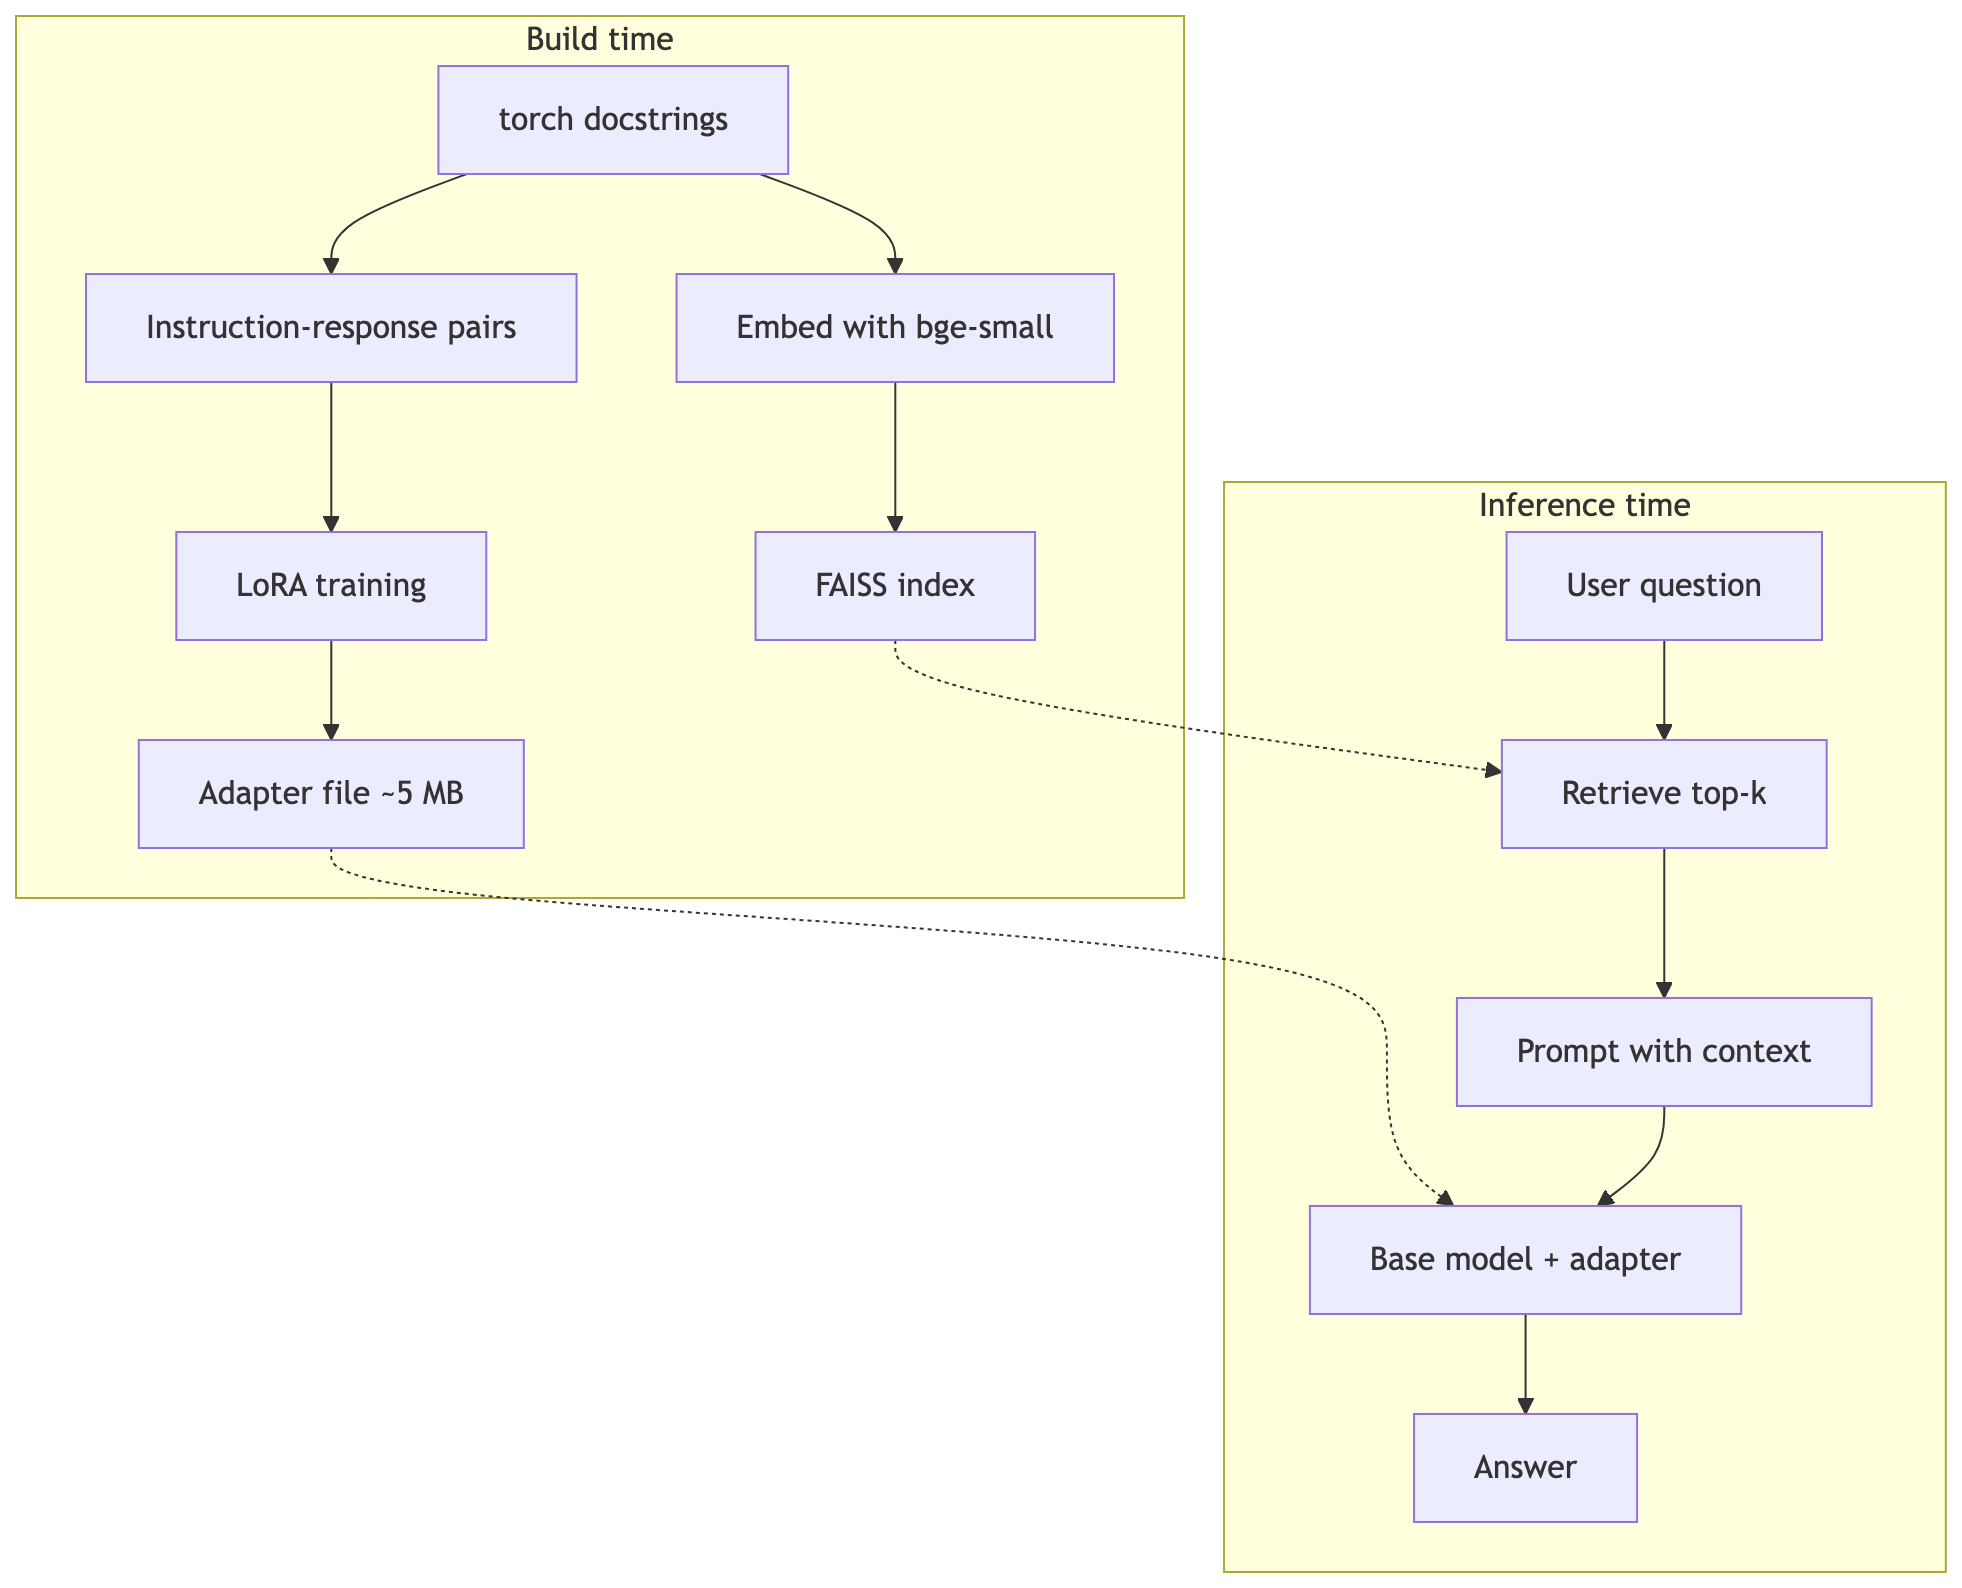

## Background: Why LoRA?

Full fine-tuning of even a small model is expensive. For Qwen 2.5-0.5B (about 500 million parameters), you would need gradients and optimizer states for every weight, totalling several GB of GPU memory.

LoRA (Low-Rank Adaptation) sidesteps this. Instead of updating each weight matrix $W$ directly, it freezes $W$ and learns a small low-rank update:

$$W' = W + \Delta W, \quad \Delta W = B A$$

where:

- $W \in \mathbb{R}^{d \times d}$ is the frozen pretrained weight.
- $A \in \mathbb{R}^{r \times d}$ is trainable, initialized with small random values.
- $B \in \mathbb{R}^{d \times r}$ is trainable, initialized to zero (so $\Delta W = 0$ at the start of training).
- $r$ is the rank, much smaller than $d$ (typically 4 to 64).

The trainable parameter count drops from $d \cdot d$ to $2 \cdot d \cdot r$. For $d = 1024$ and $r = 8$, that is a 64x reduction per matrix.

**What we do not train**: the base model weights stay frozen, so the model retains everything it learned during pretraining.

**What we train**: just $A$ and $B$ for selected projection layers, usually the attention block's `q_proj`, `k_proj`, `v_proj`, and `o_proj`.

The output of training is a tiny *adapter file*. To use the fine-tuned model later, you load the original base model and apply the adapter on top.

> **Note:** LoRA is one member of a family of parameter-efficient fine-tuning (PEFT) methods. Others include prefix tuning, prompt tuning, and IA3. LoRA is the most widely used because it has minimal inference overhead and composes cleanly with quantization (QLoRA).

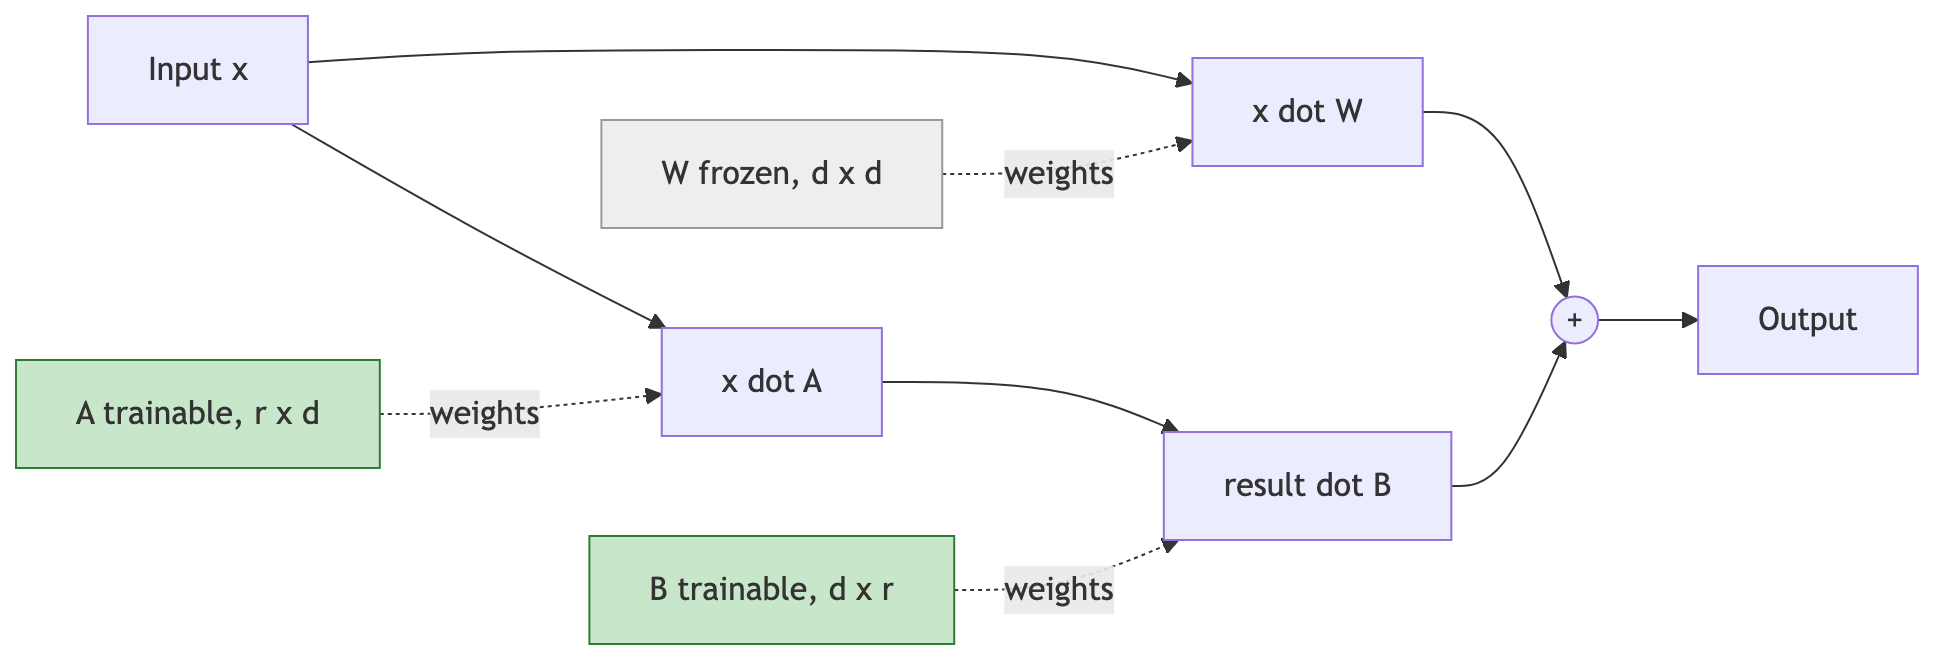

## Background: Why also RAG?

LoRA can teach the model *how* to answer (terse, code-first, consistent format), but it is a bad way to teach *facts*. A 0.5B model fine-tuned on PyTorch docstrings will still hallucinate argument names because:

- The dataset is small (we only have about 1000 API entries).
- The model is small, so memorization capacity is limited.
- LoRA's whole point is to make minimal weight changes.

RAG solves this by giving the model the relevant docs *at the time it answers*. At inference:

1. Embed the user question into a vector.
2. Look up the top-k most similar docstrings in a vector index.
3. Stuff those docstrings into the prompt as context.
4. Ask the LoRA-fine-tuned model to answer using that context.

The model no longer needs to *know* the API. It needs to know how to *use* retrieved context. That is exactly what LoRA is good at teaching.

**How LoRA and RAG divide the work:**

| Piece | Owns |
|-------|------|
| RAG   | Facts: real signatures, real argument names, current API |
| LoRA  | Style: short answers, code-first format, when to cite which module |

If you skip LoRA, the base 0.5B model will ramble or ignore the format. If you skip RAG, LoRA alone will confidently invent argument names. Together they cover each other's weakness.

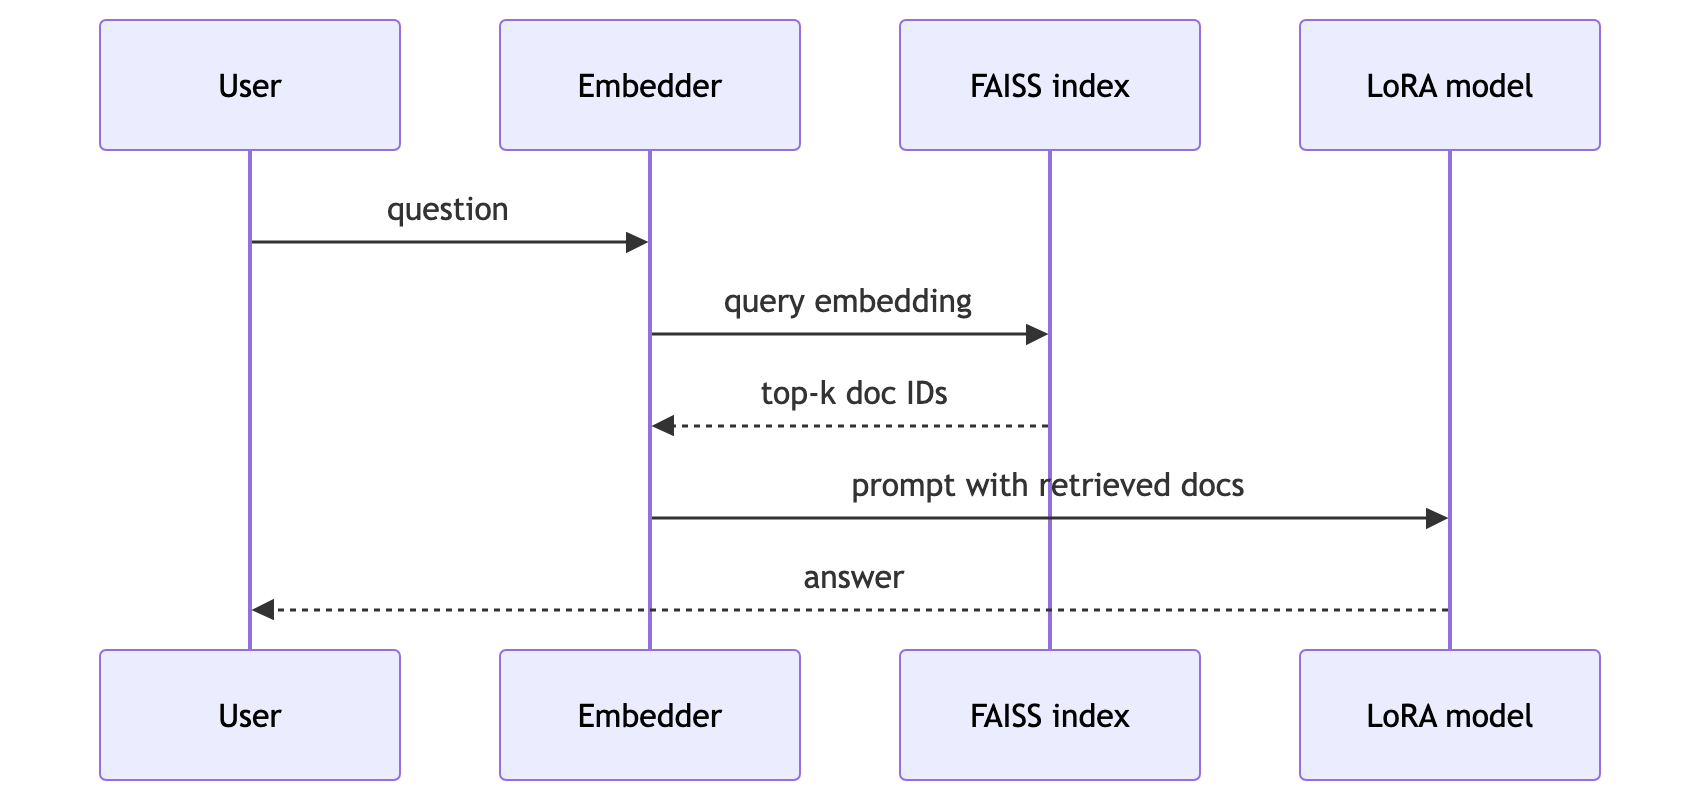

## Setup

Make sure your Colab runtime is set to a GPU: **Runtime > Change runtime type > T4 GPU**.

Install the libraries we need.

In [ ]:
!pip install -q -U transformers peft datasets accelerate sentence-transformers faiss-cpu torchao
# After this cell finishes, click Runtime > Restart session, then continue from the next cell.
# Restart is needed once because Colab preinstalls an older torchao that the current peft refuses to load.

Mount Google Drive so the adapter, dataset, and FAISS index persist across Colab sessions.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
OUT = "/content/drive/MyDrive/qwen-pytorch-lora"
os.makedirs(OUT, exist_ok=True)
print(f"All outputs will be saved to: {OUT}")

## Build the Training Dataset from PyTorch Docstrings

The cleanest source of PyTorch documentation is the `torch` module itself. Every public function and class carries a docstring with a description, signature, and often a worked example.

We extract these with `inspect`, then convert them into instruction-response pairs.

### Extract API metadata

In [ ]:
import inspect
import torch
import json

def collect_api_docs(module, prefix):
    items = []
    for name in dir(module):
        if name.startswith("_"):
            continue
        obj = getattr(module, name)
        if not callable(obj):
            continue
        doc = inspect.getdoc(obj)
        if not doc or len(doc) < 50:
            continue
        try:
            sig = str(inspect.signature(obj))
        except (ValueError, TypeError):
            sig = "(...)"
        items.append({
            "api": f"{prefix}.{name}",
            "signature": sig,
            "doc": doc,
        })
    return items

apis = []
apis += collect_api_docs(torch, prefix="torch")
apis += collect_api_docs(torch.nn, prefix="torch.nn")
apis += collect_api_docs(torch.nn.functional, prefix="torch.nn.functional")

print(f"Collected {len(apis)} API entries")
print("\nSample entry:")
print(json.dumps(apis[0], indent=2)[:500])

### Convert API entries into instruction-response pairs

For each API we generate two training examples: one asking about the signature, one asking about behavior. This is a deliberate format we are teaching the model to follow.

In [ ]:
def make_pairs(api_entry):
    api = api_entry["api"]
    sig = api_entry["signature"]
    summary = api_entry["doc"].split("\n\n")[0].strip()
    return [
        {
            "instruction": f"What is the signature of {api}?",
            "response": f"{api}{sig}",
        },
        {
            "instruction": f"What does {api} do?",
            "response": summary,
        },
    ]

pairs = [p for entry in apis for p in make_pairs(entry)]
print(f"Generated {len(pairs)} training pairs")
print("\nSample pair:")
print(json.dumps(pairs[0], indent=2))

with open(f"{OUT}/pairs.jsonl", "w") as f:
    for p in pairs:
        f.write(json.dumps(p) + "\n")
with open(f"{OUT}/apis.json", "w") as f:
    json.dump(apis, f)

## LoRA Fine-Tuning

Now we load Qwen 2.5-0.5B, attach LoRA adapters, and train on our dataset.

### Load the base model

We load in `float16` because Colab's T4 GPU does not have efficient `bfloat16` support. If you are on an A100 or L4, switch to `bfloat16` for better numerical stability.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = "Qwen/Qwen2.5-0.5B"
tok = AutoTokenizer.from_pretrained(model_id)
tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="cuda",
)

### Configure LoRA

Each argument controls a knob in the adapter:

- `r=16`: rank of the low-rank decomposition. Higher means more capacity but more parameters.
- `lora_alpha=32`: scaling factor applied to the adapter's contribution. The effective scale is `lora_alpha / r`.
- `lora_dropout=0.05`: dropout on the adapter's input. Helps avoid overfitting on small datasets.
- `target_modules`: which weight matrices get adapters. We target all four attention projections, which generally gives the best quality-cost tradeoff.

> **Note:** A common starting point is `r=8, lora_alpha=16`. We bump both because our task is format-heavy and a touch more capacity helps the model learn the answer template cleanly.

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

### Tokenize the dataset

We format each pair as:

```
### Instruction: <question>
### Response: <answer><eos>
```

The model learns to predict every token in the sequence. At inference we will provide everything up to `### Response:` and let it generate the rest.

In [ ]:
from datasets import Dataset

def format_example(p):
    text = (
        f"### Instruction: {p['instruction']}\n"
        f"### Response: {p['response']}{tok.eos_token}"
    )
    enc = tok(text, truncation=True, max_length=256, padding="max_length")
    enc["labels"] = enc["input_ids"].copy()
    return enc

ds = Dataset.from_list(pairs)
ds = ds.map(format_example, remove_columns=ds.column_names)
print(f"Tokenized {len(ds)} examples")

### Train

For 1 epoch on a few thousand examples, expect about 3 to 5 minutes on T4. Watch the loss go down in the logs.

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=f"{OUT}/checkpoints",
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=1,
        learning_rate=2e-4,
        fp16=True,
        logging_steps=20,
        save_strategy="no",
        report_to="none",
    ),
    train_dataset=ds,
    data_collator=DataCollatorForLanguageModeling(tok, mlm=False),
)
trainer.train()

model.save_pretrained(f"{OUT}/adapter")
print(f"Adapter saved to {OUT}/adapter")

## Build the RAG Index

We embed every API doc once and store the vectors in a FAISS index. At query time we embed the question and pull the most similar docs.

`bge-small-en-v1.5` is a small, fast embedding model (33 MB) that performs well on technical text. We normalize embeddings so inner product equals cosine similarity.

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")

texts = [f"{a['api']}{a['signature']}\n{a['doc']}" for a in apis]
embeddings = embedder.encode(
    texts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)
embeddings = np.asarray(embeddings, dtype="float32")

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

faiss.write_index(index, f"{OUT}/docs.faiss")
print(f"Index built with {index.ntotal} entries")

### Quick retrieval sanity check

Before plugging this into the model, confirm that retrieval returns something sensible for a few example queries.

In [ ]:
def retrieve(query, k=3):
    q_emb = embedder.encode([query], normalize_embeddings=True)
    q_emb = np.asarray(q_emb, dtype="float32")
    scores, ids = index.search(q_emb, k)
    return [(apis[i], float(s)) for i, s in zip(ids[0], scores[0])]

for q in [
    "compute softmax along a dimension",
    "move tensor to GPU",
    "save model weights to disk",
]:
    print(f"\nQuery: {q}")
    for entry, score in retrieve(q, k=3):
        print(f"  {score:.3f}  {entry['api']}")

## Inference with LoRA and RAG Together

We now combine everything. The inference function:

1. Retrieves the top 3 relevant docstrings for the question.
2. Builds a prompt that includes those docstrings as context.
3. Asks the LoRA-tuned model to answer using that context.

In [ ]:
def answer(question, k=3, max_new_tokens=150):
    docs = retrieve(question, k=k)
    context = "\n\n".join(
        f"{d['api']}{d['signature']}\n{d['doc'][:300]}"
        for d, _ in docs
    )
    prompt = (
        "Use the following PyTorch docs to answer the question. "
        "Be concise: one short code snippet and one sentence of explanation.\n\n"
        f"DOCS:\n{context}\n\n"
        f"### Instruction: {question}\n### Response:"
    )
    inputs = tok(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tok.eos_token_id,
        )
    response = tok.decode(
        out[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return response.strip()

questions = [
    "How do I compute the softmax of a tensor along dim 1?",
    "How do I move a tensor to GPU?",
    "What does torch.no_grad do?",
    "How do I save model weights to disk?",
]
for q in questions:
    print(f"\nQ: {q}")
    print(f"A: {answer(q)}")

### Ablation: try without RAG

To see what RAG buys us, run the same questions with no retrieved context. You should see the model start to invent argument names or drift off-topic.

In [ ]:
def answer_no_rag(question, max_new_tokens=150):
    prompt = f"### Instruction: {question}\n### Response:"
    inputs = tok(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tok.eos_token_id,
        )
    return tok.decode(
        out[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()

for q in questions:
    print(f"\nQ: {q}")
    print(f"A (no RAG): {answer_no_rag(q)}")

## Resuming Later

Future sessions only need the installs cell, the Drive mount cell, and the cell below. Everything else is cached on Drive.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sentence_transformers import SentenceTransformer
import faiss, json, torch
import numpy as np

model_id = "Qwen/Qwen2.5-0.5B"
tok = AutoTokenizer.from_pretrained(model_id)
tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.float16, device_map="cuda"
)
model = PeftModel.from_pretrained(base, f"{OUT}/adapter").to("cuda")

embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")
index = faiss.read_index(f"{OUT}/docs.faiss")
with open(f"{OUT}/apis.json") as f:
    apis = json.load(f)

print("Loaded model, adapter, and index. Use `answer(question)` to query.")

## Next Steps

A few directions to take this further once the basic pipeline works.

- **Better dataset.** Have a larger model (Claude, GPT-4) paraphrase the questions so the model sees a variety of phrasings, not just the two templates per API we generated here. You can also add multi-turn examples or harder "how do I do X if Y" composition questions.
- **Larger base model.** Qwen 2.5-1.5B fits on a T4 in fp16. The 7B variant needs an A100 or L4, or 4-bit quantization with `bitsandbytes` (QLoRA). With QLoRA the adapter trains the same way, only the base model loading changes.
- **Better retrieval.** Chunk long docstrings into smaller passages, use a reranker (`bge-reranker-base`) to reorder the top 20 retrieved items before picking top 3, or extend the corpus with PyTorch tutorial pages.
- **Evaluation.** Hand-curate 50 question and answer pairs as a held-out set. Measure exact-match on API names and signatures. Compare the same questions with and without LoRA, and with and without RAG, to confirm each piece is pulling its weight.
- **Serving.** Merge the adapter into the base model with `model.merge_and_unload()` for a single deployable checkpoint, or keep them separate and use `peft` at load time if you want to swap adapters per use case.

That is the full LoRA plus RAG loop on a small budget. The same recipe scales up: bigger base model, bigger corpus, better embeddings, same architecture.